# 05 — Results: collation across all schemes — CSE-CIC-IDS2018 — Mutual Information study

Reads every `runs/<scheme>/<model>/metrics.json` plus the CV tables and produces the
comparison tables and plots. **Every number here comes from a saved artifact file.**
The final section also compares this study's selected features against the base
(RF-importance) study's top 40, when that study's artifacts are present.

In [1]:
DATASET = "cic2018"
FT_ROOT = "ft40_mi"

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids import config
from ids.evaluation.cross_val import METRIC_NAMES

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "05_results.log", "nb05")

rows = []
for mp in sorted(P.runs.glob("*/*/metrics.json")):
    d = nbc.load_json(mp)
    for split in ("test", "validation"):
        if split in d:
            m = {k: v for k, v in d[split].items() if k != "name"}
            rows.append({"scheme": d["scheme"], "model": d["model"], "split": split,
                         "n_train": d["n_train"], "fit_seconds": d["fit_seconds"], **m})
summary = pd.DataFrame(rows)
summary.to_csv(P.results / "summary_all_schemes.csv", index=False)
log.info("collected %d (scheme, model, split) results", len(summary))
summary.head(10)

2026-07-06 20:27:39,700 INFO nb05: collected 25 (scheme, model, split) results


,scheme,model,split,n_train,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,detection_time_ms,n_test
0,70_20_10,decision_tree,test,1110830,20.181,0.719953,0.652537,0.769886,0.669533,0.911404,0.000280,158691
1,70_20_10,decision_tree,validation,1110830,20.181,0.719999,0.656991,0.784784,0.675212,0.912462,0.000281,317381
2,70_20_10,knn,test,1110830,4.530,0.721812,0.598458,0.788899,0.624116,0.928111,0.544645,158691
3,70_20_10,knn,validation,1110830,4.530,0.719662,0.603477,0.823672,0.628507,0.927502,0.523477,317381
4,70_20_10,naive_bayes,test,1110830,5.139,0.418814,0.329462,0.585886,0.346048,0.821245,0.000676,158691
5,70_20_10,naive_bayes,validation,1110830,5.139,0.422020,0.330601,0.643536,0.346778,0.822216,0.000641,317381
6,70_20_10,random_forest,test,1110830,41.392,0.754265,0.647095,0.786943,0.656088,0.950604,0.005575,158691
7,70_20_10,random_forest,validation,1110830,41.392,0.752421,0.684148,0.834089,0.698249,0.950308,0.005471,317381
8,70_20_10,svm,test,1110830,10.016,0.415342,0.387697,0.669115,0.405907,0.856862,0.001165,158691
9,70_20_10,svm,validation,1110830,10.016,0.417126,0.387345,0.733850,0.404463,0.857420,0.001968,317381


## 1. Test-set comparison: model × scheme, one table per metric

In [3]:
test = summary[summary["split"] == "test"]
pivots = {}
for metric in METRIC_NAMES + ["detection_time_ms", "fit_seconds"]:
    pv = test.pivot_table(index="model", columns="scheme", values=metric).round(4)
    pv.to_csv(P.results / f"pivot_{metric}.csv")
    pivots[metric] = pv
log.info("saved %d pivot tables to %s", len(pivots), P.results)
pivots["f1_macro"]

2026-07-06 20:27:39,743 INFO nb05: saved 7 pivot tables to /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2018/results


scheme,70_20_10,70_30,80_20,90_10
model,,,,
decision_tree,0.6695,0.6624,0.6727,0.6782
knn,0.6241,0.6292,0.6334,0.6202
naive_bayes,0.3460,0.3428,0.3569,0.3206
random_forest,0.6561,0.6775,0.6773,0.6744
svm,0.4059,0.3859,0.3950,0.4018


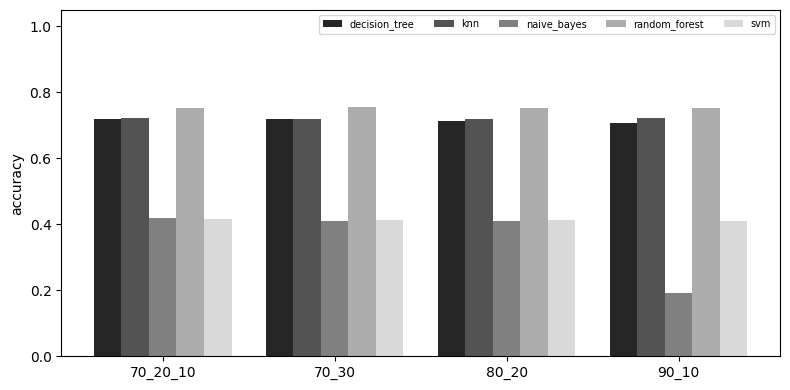

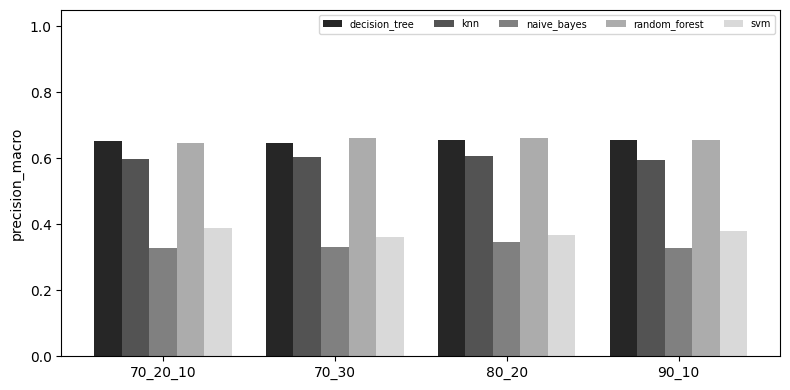

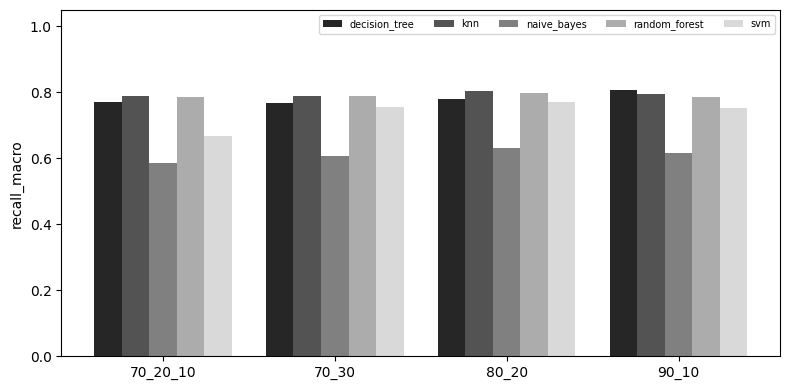

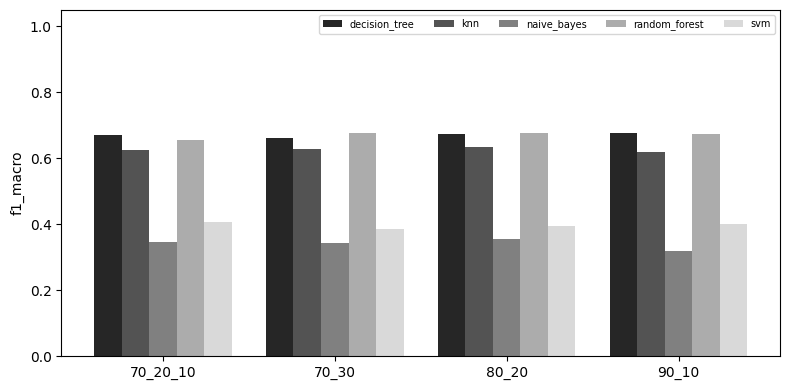

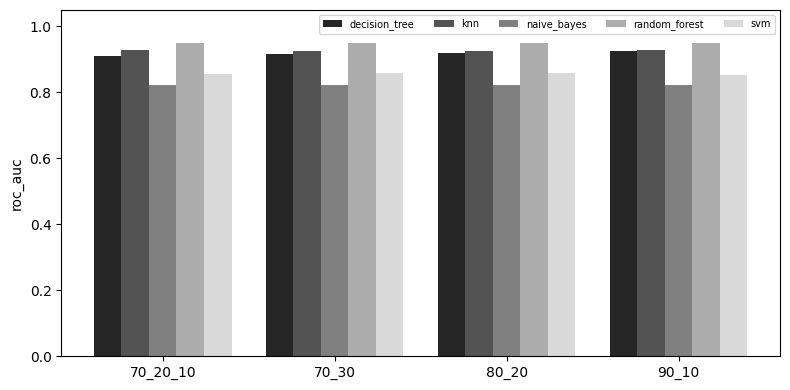

In [4]:
for metric in METRIC_NAMES:
    pv = pivots[metric]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pv.columns))
    width = 0.8 / len(pv.index)
    for i, model in enumerate(pv.index):
        ax.bar(x + i * width, pv.loc[model], width,
               label=model, color=str(0.15 + 0.7 * i / max(1, len(pv.index) - 1)))
    ax.set_xticks(x + 0.4 - width / 2)
    ax.set_xticklabels(pv.columns)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, ncol=len(pv.index))
    fig.tight_layout()
    fig.savefig(P.results / "plots" / f"{metric}_by_scheme.png", dpi=150)
    plt.show()

## 2. Cross-validation (cv5): mean ± std per model

In [5]:
cv_summary_path = P.runs / "cv5" / "cv_summary.csv"
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    cv_summary.to_csv(P.results / "cv5_summary.csv", index=False)
    display(cv_summary.round(4))
else:
    log.warning("no cv5 results found at %s", cv_summary_path)

,model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,decision_tree,0.7237,0.0150,0.6509,0.0083,0.8050,0.0329,0.6685,0.0106,0.9191,0.0034
1,knn,0.7197,0.0016,0.6011,0.0084,0.8152,0.0285,0.6228,0.0107,0.9267,0.0006
2,naive_bayes,0.2863,0.1021,0.3268,0.0133,0.5983,0.0277,0.3307,0.0155,0.8292,0.0018
3,random_forest,0.7435,0.0014,0.6308,0.0101,0.8088,0.0377,0.6407,0.0133,0.9505,0.0003
4,svm,0.4111,0.0139,0.3572,0.0132,0.7320,0.0255,0.3813,0.0111,0.8577,0.0114


## 3. Validation vs test on the 70/20/10 scheme

In [6]:
vt = summary[summary["scheme"] == "70_20_10"].pivot_table(
    index="model", columns="split",
    values=[m for m in METRIC_NAMES if m in summary.columns]).round(4)
vt.to_csv(P.results / "val_vs_test_70_20_10.csv")
vt

accuracy            f1_macro            precision_macro  \
split             test validation     test validation            test   
model                                                                   
decision_tree   0.7200     0.7200   0.6695     0.6752          0.6525   
knn             0.7218     0.7197   0.6241     0.6285          0.5985   
naive_bayes     0.4188     0.4220   0.3460     0.3468          0.3295   
random_forest   0.7543     0.7524   0.6561     0.6982          0.6471   
svm             0.4153     0.4171   0.4059     0.4045          0.3877   

                         recall_macro            roc_auc             
split         validation         test validation    test validation  
model                                                                
decision_tree     0.6570       0.7699     0.7848  0.9114     0.9125  
knn               0.6035       0.7889     0.8237  0.9281     0.9275  
naive_bayes       0.3306       0.5859     0.6435  0.8212     0.8222  
random_forest     0.6841       0.7869     0.8341  0.9506     0.9503  
svm               0.3873       0.6691     0.7339  0.8569     0.8574

## 4. Feature-set overlap with the base (RF-importance) study

In [7]:
mine = nbc.load_json(P.features / "top40.json")
base_path = config.ARTIFACTS_DIR / "ft40" / DATASET / "features" / "top40.json"
if base_path.exists():
    base = nbc.load_json(base_path)
    shared = sorted(set(mine["selected"]) & set(base["selected"]))
    only_mine = sorted(set(mine["selected"]) - set(base["selected"]))
    only_base = sorted(set(base["selected"]) - set(mine["selected"]))
    overlap = {"method": mine.get("method"), "n_shared_with_rf_importance": len(shared),
               "shared": shared, "only_this_method": only_mine, "only_rf_importance": only_base}
    nbc.save_json(overlap, P.results / "feature_overlap_vs_base.json")
    log.info("%d/40 features shared with the RF-importance study", len(shared))
    print(f"shared with base study: {len(shared)}/40")
else:
    log.warning("base study top40 not found at %s — overlap skipped", base_path)

2026-07-06 20:27:40,359 INFO nb05: 34/40 features shared with the RF-importance study
shared with base study: 34/40


## 5. Artifact inventory (what backs every number above)

In [8]:
inventory = sorted(str(p.relative_to(P.root)) for p in P.root.rglob("*") if p.is_file())
nbc.save_json(inventory, P.results / "artifact_inventory.json")
log.info("study produced %d artifact files under %s", len(inventory), P.root)
print(f"{len(inventory)} files; key results:")
for f in inventory:
    if f.startswith("results/") and f.endswith(".csv"):
        print(" ", f)

2026-07-06 20:27:40,373 INFO nb05: study produced 183 artifact files under /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2018
183 files; key results:
  results/cv5_summary.csv
  results/pivot_accuracy.csv
  results/pivot_detection_time_ms.csv
  results/pivot_f1_macro.csv
  results/pivot_fit_seconds.csv
  results/pivot_precision_macro.csv
  results/pivot_recall_macro.csv
  results/pivot_roc_auc.csv
  results/summary_all_schemes.csv
  results/val_vs_test_70_20_10.csv
